# Per-gene support under tree perturbation

On a real lineage tree there is no ground truth for a gene's regime, so a SCOUT call can't be scored directly. What we *can* ask is whether a call **survives when the tree is wrong**. A regime call that depends on fine details of the reconstructed topology is fragile. One that persists under moderate topological error is better supported by the data.

This vignette follows `scripts/gene_support_cele_bl_runner.R` on the *C. elegans* lineage (rpl subset, branch-length tree):

1. **Perturb the tree.** Build a ladder of degraded copies of the reference tree, plus a full tip-shuffle that serves as the no-signal floor.
2. **Inspect the manifest.** It is the table that indexes every tree.
3. **Run gene support.** Fit SCOUT model selection for every gene on every tree, then summarise how often each gene's reference call holds.

### The perturbation arms

| arm | what changes | intensity is a fraction of |
|---|---|---|
| `nni` | local topology (nearest-neighbour interchanges); branch lengths are kept | internal edges |
| `collapse` | internal edges are deleted, so topology **and** root-to-tip depths change | internal edges |
| `shuffle` | tip labels are permuted; the tree itself is untouched | tips |
| `reference` | none (polytomies resolved, zero-length edges floored) | — |

`shuffle` at intensity 1 breaks every cell↔position association, so agreement there is the floor that support should be compared against, not zero.

In [7]:
detach("package:SCOUT", unload = TRUE)


In [1]:
suppressWarnings(suppressPackageStartupMessages({
    library(SCOUT)
    library(ape)
    library(dplyr)
}))

# Perturbation + gene-support helpers. Both live in SCOUT/scripts/ (not part of the package).
scout_dir <- './SCOUT'
source(file.path(scout_dir, 'scripts', 'scout_perturb_lib.R'))   # perturb_tree(), resolve_and_floor(), score_classification()
source(file.path(scout_dir, 'scripts', 'gene_support.R'))        # make_perturbed_trees(), run_gene_support(), gene_support(), ...

## 1. Configuration

`perturb.config` defines the perturbation grid. Each `(arm, intensity)` pair in `arms × intensities` gets `n_rep` replicate trees. The `shuffle` arm is always added at `shuffle_at`, and one reference tree is added. 

Note: Each tree's seed is a deterministic function of arm, intensity, replicate and `seed_tree`. Re-running the grid therefore regenerates the same trees, and adding an intensity does not shift the seeds of existing ones.

In [2]:
perturb.config <- list(
    arms        = c('nni', 'collapse'),
    n_rep       = 30,
    intensities = c(0.05, 0.1, 0.15, 0.2, 0.25, 0.5, 0.75),
    shuffle_at  = 1.00,
    seed_tree   = 2000,
    cores       = 24          # used by run_gene_support() for the SCOUT fits
)

data_root <- './SCOUT'
cele.obj <- list(
    name       = 'cele_bl_v2',
    label      = 'C. elegans lineage (rpl subset0)',
    treepath   = file.path(data_root, 'data/cele_cell_lineage_rpl.nwk'),
    countspath = file.path(data_root, 'data/celegans_random_precise_lineage_mincells_20_metadata.csv'),
    genes      = file.path(data_root, 'data/celegans_rpl_gene_list.txt'),
    # perturbed trees, manifest and per-tree fit checkpoints are written here
    outpath    = file.path('output', 'cele_bl_v2')
)

In [3]:
# Rescale for C. elegans 
MakeAgeTable <- function(phy, root.age = NULL) {
    if (is.null(root.age)) root.age <- max(node.depth.edgelength(phy))
    node.ages <- paleotree::dateNodes(phy, rootAge = root.age)
    max.age <- max(node.ages)
    cbind(max.age - node.ages[phy$edge[, 1]],
          max.age - node.ages[phy$edge[, 2]])
}

cele.obj$phy <- read.tree(cele.obj$treepath)
Tmax.i <- max(MakeAgeTable(cele.obj$phy))
cele.obj$phy$edge.length <- cele.obj$phy$edge.length / Tmax.i

cat(sprintf('%d tips, binary = %s, height after scaling = %.3f\n',
            Ntip(cele.obj$phy), is.binary(cele.obj$phy), max(node.depth.edgelength(cele.obj$phy))))

391 tips, binary = TRUE, height after scaling = 1.000


## 3. Build the perturbed tree set

`make_perturbed_trees()` writes one `.nwk` per tree to `outpath` and returns a list with two elements:

- `trees`: the `phylo` objects, in manifest order. These are what get fitted, so nothing is re-read from newick (a write/read round-trip renumbers internal nodes).
- `manifest`: one row per tree.

It warns if any perturbed tree has Robinson–Foulds distance 0 to the reference, i.e. an arm that turned out to be a no-op.

In [4]:
cele_perturb <- make_perturbed_trees(cele.obj, perturb.config, cele.obj$outpath)
cat(sprintf('%d trees written to %s\n', nrow(cele_perturb$manifest), cele.obj$outpath))

451 trees written to output/cele_bl_v2


### The manifest

| column | meaning |
|---|---|
| `arm`, `intensity`, `replicate` | position in the perturbation grid |
| `k` | number of units actually perturbed (edges for nni/collapse, tips for shuffle) |
| `seed` | the RNG seed that produced this tree |
| `stem` | unique id; it names both the `.nwk` file and the fit checkpoint |
| `tree_file` | path to the written `.nwk` (dropped from the display below) |
| `rf_dist` | normalised Robinson–Foulds distance to the reference (needs `phangorn`) |
| `height`, `depth_cv` | max root-to-tip depth, and the CV of root-to-tip depths (0 = ultrametric) |
| `n_internal` | internal edges remaining (drops under `collapse`) |

In [5]:
head(select(cele_perturb$manifest, -tree_file), 10)

,tree,arm,intensity,replicate,k,seed,stem,rf_dist,height,depth_cv,n_internal
,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<int>
1,cele_bl_v2,reference,0.00,1,0,NA,cele_bl_v2_reference_i000_rep001,0.00000000,1.0000000,0.1893951,389
2,cele_bl_v2,nni,0.05,1,19,22051,cele_bl_v2_nni_i005_rep001,0.04639175,1.0107914,0.2031494,389
3,cele_bl_v2,collapse,0.05,1,19,32051,cele_bl_v2_collapse_i005_rep001,0.03350515,1.0000001,0.1941165,389
4,cele_bl_v2,nni,0.10,1,39,22101,cele_bl_v2_nni_i010_rep001,0.08762887,1.0779376,0.1970115,389
5,cele_bl_v2,collapse,0.10,1,39,32101,cele_bl_v2_collapse_i010_rep001,0.06701031,1.0000001,0.2204564,389
6,cele_bl_v2,nni,0.15,1,58,22151,cele_bl_v2_nni_i015_rep001,0.13402062,1.0923261,0.2106803,389
7,cele_bl_v2,collapse,0.15,1,58,32151,cele_bl_v2_collapse_i015_rep001,0.12371134,1.0000000,0.2317616,389
8,cele_bl_v2,nni,0.20,1,78,22201,cele_bl_v2_nni_i020_rep001,0.17010309,1.1618705,0.2307481,389
9,cele_bl_v2,collapse,0.20,1,78,32201,cele_bl_v2_collapse_i020_rep001,0.13402062,0.9760195,0.2227895,389


Averaged over replicates, `rf_dist` should rise with intensity in both arms. `shuffle` should sit near 1.

Note `height` and `depth_cv`. NNI moves subtrees without re-timing them, and collapse merges edges, so both arms break ultrametricity (`depth_cv` grows with intensity). That is a confound in its own right. Only `shuffle` degrades the tree while leaving its shape untouched.

In [6]:
cele_perturb_summary <- cele_perturb$manifest %>%
    group_by(arm, intensity) %>%
    summarise(n = n(), k = first(k), rf_mean = mean(rf_dist), rf_sd = sd(rf_dist),
              height = mean(height), depth_cv = mean(depth_cv), .groups = 'drop') %>%
    mutate(across(c(rf_mean, rf_sd, height, depth_cv), ~ signif(.x, 4)))

write.csv(cele_perturb$manifest, file.path(cele.obj$outpath, paste0(cele.obj$name, '_manifest.csv')))
write.csv(cele_perturb_summary,  file.path(cele.obj$outpath, paste0(cele.obj$name, '_manifest_summary.csv')))
cele_perturb_summary

arm,intensity,n,k,rf_mean,rf_sd,height,depth_cv
<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
collapse,0.05,30,19,0.03290,0.005359,0.9953,0.2007
collapse,0.10,30,39,0.07019,0.010010,0.9898,0.2124
collapse,0.15,30,58,0.10810,0.008875,0.9801,0.2243
collapse,0.20,30,78,0.14740,0.010270,0.9601,0.2398
collapse,0.25,30,97,0.19030,0.011270,0.9506,0.2534
collapse,0.50,30,194,0.42890,0.013860,0.8825,0.3270
collapse,0.75,30,292,0.71210,0.008619,0.7802,0.4149
nni,0.05,30,19,0.04648,0.003349,1.0790,0.2004
nni,0.10,30,39,0.09278,0.006562,1.1200,0.2107


## 4. Prepare the expression table

`run_gene_support()` takes a single wide table: a `species` column matching the tree's tip labels, the regime-partition columns, and one column per gene. Here the gene set is the 120-gene evenly-sampled list. Regime columns are kept by name (`OUalt`, `OUl`); every other metadata column is dropped.

In [7]:
sampled_meta  <- read.csv(cele.obj$countspath)
genes_to_keep <- read.table(cele.obj$genes)[, 1]

mask_cols    <- c('species', 'OUalt', 'OUl')     # tip ids + candidate regime partitions
sampled_meta <- sampled_meta[, c(mask_cols, genes_to_keep)]

stopifnot(setequal(sampled_meta$species, cele.obj$phy$tip.label))
cat(sprintf('%d cells x %d genes\n', nrow(sampled_meta), length(genes_to_keep)))
head(sampled_meta[, 1:6])

391 cells x 120 genes


,species,OUalt,OUl,D1086.12,C03C10.9,somi.1
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,ABalaaaalp,AB,AB,0,0.0000,0
2,ABalaaaarr,AB,AB,0,0.0000,0
3,ABalaaapall,AB,AB,0,0.0000,0
4,ABalaaappl,AB,AB,0,0.0000,0
5,ABalaaapprr,AB,AB,0,0.0000,0
6,ABalaapaaa,AB,AB,0,1.1275,0


## 5. Run gene support

For every tree in the manifest, `run_gene_support()` runs SCOUT model selection over the candidate `regimes` for every gene. Here those are `BM1` and `OU1` plus the two partition columns. SCOUT only **scores** the partitions you give it and never searches for new ones, so every hypothesis has to be a column in `meta`.

- `layer = 'expression'`: the input is already on a fittable scale and is not normalised again. Use `'counts'` for raw counts.
- Each tree's fit is checkpointed to `outpath/support_<layer>_<gene-set hash>/<stem>.rds`. A re-run picks up the cached fits, so an interrupted job resumes where it left off. Pass `force = TRUE` to refit.
- The function stops if the fitted gene set differs between trees, since per-gene support would then have a moving denominator.

*Note: This run equates to ~35 SCOUT runs, so we don't recommend running the full job from this notebook. An already run file is included in ./data (see section 6)*

In [ ]:
obs_cfg <- list(
    meta     = sampled_meta,
    gene_set = genes_to_keep,
    name     = cele.obj$name,
    regimes  = c('BM1', 'OU1', 'OUalt', 'OUl'),
    outdir   = cele.obj$outpath
)

res <- run_gene_support(obs_cfg, cele_perturb, layer = 'expression', cores = perturb.config$cores)
cat(sprintf('\ntotal compute: %.1f min over %d fits of %d genes\n',
            sum(res$meta$elapsed_min), nrow(res$meta), length(res$genes)))
saveRDS(res, file.path(cele.obj$outpath, paste0(cele.obj$name, '_gene_support.rds')))

## 6. Model Selection and Analysis 

In [1]:
library(dplyr)
library(tidyverse)
library(patchwork)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   4.0.3     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.0
✔ purrr     1.2.0     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
regs_colors <- c("OU1" = "#E7A44D","OUl" = "#5D2B47","OUalt" = "#DFB2C9", "OUM" = "#AC638B", "BM1" = "#BCBCBC", "ignore" = "#1F2346", 
           "non-scout" = "#5861A5")

In [12]:
datadr <- '../data'
scout_predix <- 'celegans_rpl_gene_support_reps1-5'

In [13]:
full_history <- read.csv(sprintf('%s/%s_full_history.csv',datadr, scout_predix))

In [13]:
# Model selection using AICc and LRT for adaptive genes. Failed adaptive are set to ambiguous. If user would prefer to keep these genes, set hybrid_on_fail = 'fallback' to the less parameterized model.
sel <- scout_model_selection(
    history = full_history,
    ic      = 'AICc',    # or 'AIC'
    hybrid  = TRUE,
    hybrid_on_fail = 'ambiguous')      # FALSE = select by IC alone
    
keep <- sel$gene_name[sel$final_set]

In [20]:
colnames(sel)
final_set <- sel %>% filter(final_set == TRUE)%>% separate(col = dataset, into = c('name', 'layer', 'arm','intensity', 'replicate'), sep = '\\|',
                                      convert = TRUE, remove = FALSE)
dim(final_set)

[1] "dataset"                    "gene_name"                 
 [3] "selected_regime"            "selected_model"            
 [5] "next_best_regime"           "AICc"                      
 [7] "AICc_weight"                "delta_AICc_next"           
 [9] "ll_total"                   "param.count"               
[11] "ntips"                      "alpha"                     
[13] "sigma"                      "tau"                       
[15] "iter"                       "converge"                  
[17] "n_candidates_not_converged" "ic_winner"                 
[19] "lrt_status"                 "lrt_alt"                   
[21] "lrt_statistic"              "lrt_df"                    
[23] "lrt_p_value"                "lrt_p_corrected"           
[25] "flag_not_converged"         "flag_max_iter"             
[27] "flag_oscillating"           "flag_ambiguous"            
[29] "flag_missing_fit"           "lrt_p_fdr"                 
[31] "final_set"                  "ic"

[1] 32718    37

In [25]:
ref <- final_set %>% filter(arm == 'reference') %>%
        select(gene_name, ref_call = selected_regime, ref_AIC = AICc)

match_df <- final_set %>% filter(arm != 'reference') %>%
        filter(gene_name %in% ref$gene_name) %>% 
        left_join(ref, by = 'gene_name') %>% 
        mutate(binary_match = selected_regime == ref_call)

### Visualize Gene Support 

`summarise()` has grouped output by 'layer', 'ref_call', 'arm', 'intensity'. You can override using the `.groups`
argument.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


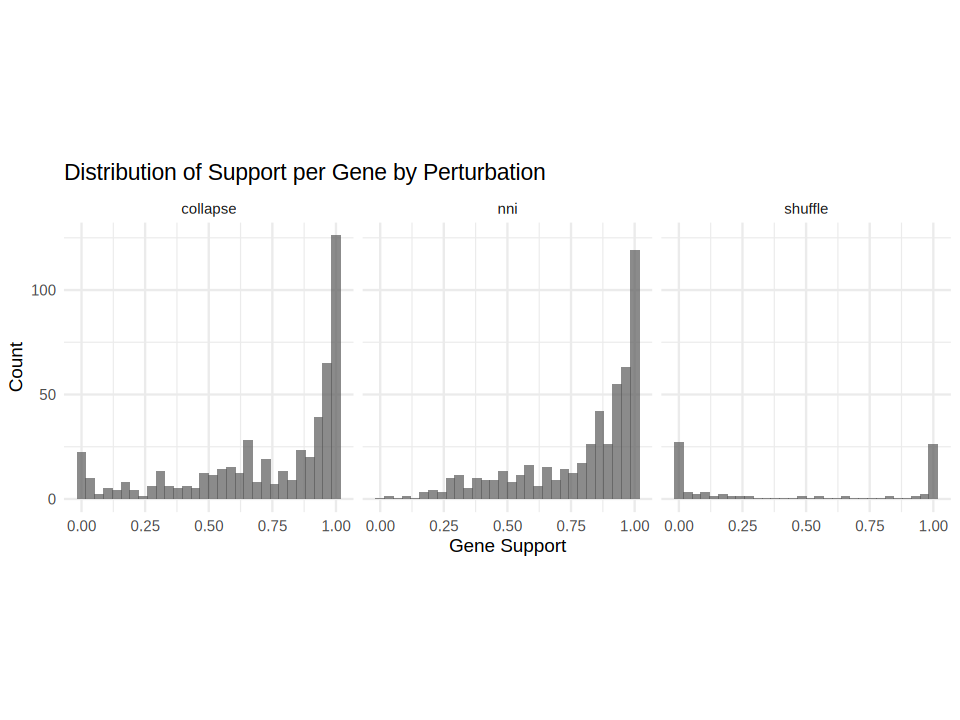

In [40]:
support_per_gene <- match_df %>% 
    group_by(layer, ref_call, arm, intensity, gene_name) %>% 
    summarize(n_trials = n(), support = sum(binary_match) / n_trials) 

ggplot(support_per_gene, aes(x = support)) + geom_histogram(alpha = 0.7) + 
    facet_grid(.~arm) + 
    theme_minimal() + labs(x = 'Gene Support', y = 'Count', title = 'Distribution of Support per Gene by Perturbation') + 
    theme(aspect.ratio = 1)
    

In [28]:
A1 <- match_df %>% filter(arm == 'nni') %>%  
    group_by(layer, ref_call, arm, intensity, gene_name) %>% 
    summarize(n_trials = n(), support = sum(binary_match) / n_trials) %>% ungroup() %>% 
    group_by(layer, ref_call, arm, intensity)  %>% 
    summarize(mSupp = mean(support), sdSupp = sd(support)) %>% 
    filter(arm != 'shuffle') %>% 
    ggplot(aes(x = intensity, y = mSupp, group = ref_call, color = ref_call)) + 
    geom_line() + geom_pointrange(aes(ymin = mSupp - sdSupp, ymax = mSupp + sdSupp)) + 
    facet_grid(.~arm) + theme(aspect.ratio = 1)+ theme_classic() + 
    scale_color_manual(values = regs_colors) + 
    theme(aspect.ratio = 1) + labs(x = 'Reference Call', y = 'Support')

A2 <- match_df %>% filter(arm == 'collapse') %>%  
    group_by(layer, ref_call, arm, intensity, gene_name) %>% 
    summarize(n_trials = n(), support = sum(binary_match) / n_trials) %>% ungroup() %>% 
    group_by(layer, ref_call, arm, intensity)  %>% 
    summarize(mSupp = mean(support), sdSupp = sd(support)) %>% 
    filter(arm != 'shuffle') %>% 
    ggplot(aes(x = intensity, y = mSupp, group = ref_call, color = ref_call)) + 
    geom_line() + geom_pointrange(aes(ymin = mSupp - sdSupp, ymax = mSupp + sdSupp)) + 
    facet_grid(.~arm) + theme(aspect.ratio = 1)+ theme_classic() + 
    scale_color_manual(values = regs_colors) + 
    theme(aspect.ratio = 1) + labs(x = 'Reference Call', y = 'Support')

B <- match_df %>% group_by(layer, arm, intensity, gene_name) %>% 
    summarize(n_trials = n(), support = sum(binary_match) / n_trials) %>% ungroup() %>% 
    group_by(layer, arm, intensity)  %>% 
    summarize(mSupp = mean(support), sdSupp = sd(support)) %>% 
    filter(arm != 'shuffle') %>% 
    ggplot(aes(x = intensity, y = mSupp, group = arm, color = arm)) + 
    geom_line() + geom_pointrange(aes(ymin = mSupp - sdSupp, ymax = mSupp + sdSupp)) + 
    theme(aspect.ratio = 1)+ theme_classic() + 
    scale_color_manual(values = c('collapse' = '#EACE26', 'nni' = '#49C1C1')) + 
    theme(aspect.ratio = 1) + labs(x = 'Reference Call', y = 'Support')

C <- match_df %>% group_by(layer, arm,ref_call, intensity, gene_name) %>% 
    summarize(n_trials = n(), support = sum(binary_match) / n_trials) %>% ungroup() %>% 
    filter(arm == 'shuffle') %>% 
    ggplot(aes(x = ref_call, y = support, fill = ref_call)) + 
    geom_boxplot() + 
    theme(aspect.ratio = 1)+ theme_classic() + 
    scale_fill_manual(values = regs_colors) + 
    theme(aspect.ratio = 1) + labs(x = 'Reference Call', y = 'Support')


`summarise()` has grouped output by 'layer', 'ref_call', 'arm', 'intensity'. You can override using the `.groups`
argument.
`summarise()` has grouped output by 'layer', 'ref_call', 'arm'. You can override using the `.groups` argument.
`summarise()` has grouped output by 'layer', 'ref_call', 'arm', 'intensity'. You can override using the `.groups`
argument.
`summarise()` has grouped output by 'layer', 'ref_call', 'arm'. You can override using the `.groups` argument.
`summarise()` has grouped output by 'layer', 'arm', 'intensity'. You can override using the `.groups` argument.
`summarise()` has grouped output by 'layer', 'arm'. You can override using the `.groups` argument.
`summarise()` has grouped output by 'layer', 'arm', 'ref_call', 'intensity'. You can override using the `.groups`
argument.


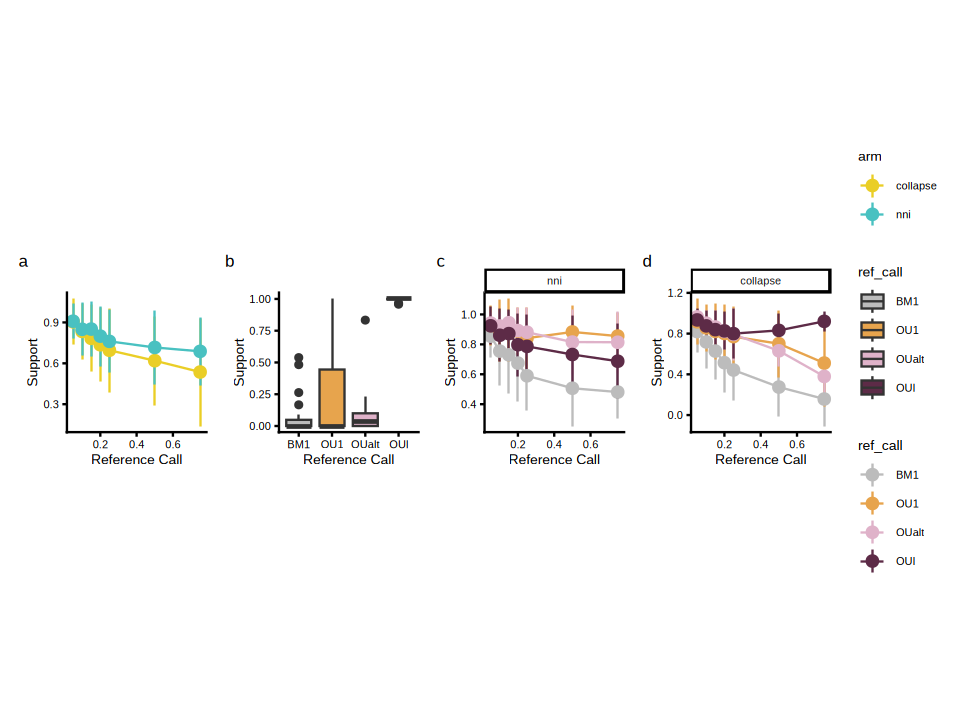

In [32]:
layout = c('ABCD')
B + C + A1 + A2 + plot_layout(design = layout, guides = 'collect') + 
    plot_annotation(tag_levels = 'a') & theme(text = element_text(size = 8))
